</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis exploratorio de datos
        </h1>
        </h1>
    </div>
</div>

### Índice:

1) Estadísticos descriptivos e interpretación clínica
2) Distribución del target y desbalanceo
3) Valores ausentes: análisis y estrategia
4) Valores atípicos e inconsistencias
5) Correlaciones y relaciones
6) Variables de texto libre y categóricas de alta cardinalidad
7) Análisis de sesgos poblaciones y equidad

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 0. Carga de librerías y del conjunto de datos

Este cuaderno está dedicado al análisis exploratorio de datos del conjunto de datos que se utilizará el sistema CARDIS, donde se analizarán diferentes aspectos de estos datos, de acuerdo con el índice previamente mostrado.

En primer lugar, se comenzará por la carga de librerías a utilizar, y del propio conjunto de datos.

In [23]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Para reproducibilidad
np.random.seed(42)


cardis_df_train = pd.read_csv(Path("../../data/raw/cardio_risk_train.csv"))
cardis_df_test = pd.read_csv(Path("../../data/raw/cardio_risk_test.csv"))

También se realizará una inspección inicial de los datos.

In [24]:
print(f"Datos de entrenamiento: {cardis_df_train.shape}")
print(f"Datos de test: {cardis_df_test.shape}")

Datos de entrenamiento: (24000, 21)
Datos de test: (16000, 20)


In [25]:
print("=== PRIMERAS 5 FILAS ===")
cardis_df_train.head()

=== PRIMERAS 5 FILAS ===


,id,fecha_visita,edad,altura_cm,peso_kg,imc,presion_sistolica_1,presion_sistolica_2,presion_sistolica_3,colesterol_total,hdl,ldl,glucosa_ayunas,fumador,actividad_fisica,antecedentes_familiares,codigo_postal,hospital_origen,notas_medicas,talla_zapato,riesgo_cv
0,3111,2018-08-07 17:59:44.789084,55,180,86.6,26.6,138.0,208.6,113.6,618.4,46.7,137.4,NaN,0.0,~0.4 horas,0,41015,HOSP-011,El paciente tiene periodos de actividad seguid...,46,0
1,18679,2022-08-02 06:32:46.789084,37,154,45.2,19.0,104.8,115.0,109.5,158.3,54.9,80.7,NaN,0.0,~2.6 horas,1,8031,HOSP-019,"EXPLORACIÓN FÍSICA COMPLETAMENTE NORMAL, SIN N...",41,0
2,17472,2022-04-10 03:55:25.789084,38,164,48.9,18.1,105.5,107.4,123.7,175.9,46.5,110.0,NaN,0.0,~3.7 horas,0,7600,HOSP-008,No se añaden nuevos diagnósticos al historial ...,34,0
3,21451,2020-04-06 05:10:09.789084,75,169,75.9,26.5,129.2,147.1,129.6,186.1,36.3,133.6,96.0,1.0,poco,0,28901,HOSP-016,paciente con alta probabilidad de padecer sínd...,44,1
4,20800,2019-08-22 22:21:21.789084,80,161,89.8,34.7,137.1,135.2,133.8,216.8,41.6,154.8,96.1,0.0,~0.0 horas,1,8907,HOSP-006,Antecedentes Familiares De Infarto De Miocardi...,39,1


In [26]:
print("=== INFORMACIÓN GENERAL ===")
cardis_df_train.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   fecha_visita             24000 non-null  object 
 2   edad                     24000 non-null  int64  
 3   altura_cm                24000 non-null  int64  
 4   peso_kg                  24000 non-null  float64
 5   imc                      24000 non-null  float64
 6   presion_sistolica_1      24000 non-null  float64
 7   presion_sistolica_2      24000 non-null  float64
 8   presion_sistolica_3      24000 non-null  float64
 9   colesterol_total         24000 non-null  float64
 10  hdl                      24000 non-null  float64
 11  ldl                      24000 non-null  float64
 12  glucosa_ayunas           13606 non-null  float64
 13  fumador                  21782 non-null  float64

Como podemos ver, existen valores nulos, que deberemos categorizar y tratar en un futuro.

In [27]:
print("=== TIPOS DE DATOS ===")
print(cardis_df_train.dtypes.value_counts())
print(f"\nTotal de columnas: {len(cardis_df_train.columns)}")

=== TIPOS DE DATOS ===
float64    10
int64       7
object      4
Name: count, dtype: int64

Total de columnas: 21


<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 1. Estadísticos descriptivos e interpretación clínica

Una vez hemos cargado el conjunto de datos, podemos comenzar con un primer análisis más extenso de este, analizando sus estadísticos descriptivos y aportando una interpretación clínica a ellos. Pero antes de ellos, es importante clasificar las diferentes variables de las que se dispone de acuerdo a su tipo, para poder analizarlas como corresponde.

In [28]:
# Clasificar variables por tipo
print("=== CLASIFICACIÓN DE VARIABLES ===")

# Variables numéricas continuas
vars_numericas_continuas = [
    'edad', 'altura_cm', 'peso_kg', 'imc',
    'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3',
    'colesterol_total', 'hdl', 'ldl', 'glucosa_ayunas'
]

# Variables categóricas binarias
vars_categoricas_binarias = [
    'fumador', 'antecedentes_familiares'
]

# Variables categóricas nominales
vars_categoricas_nominales = [
    'hospital_origen', 'codigo_postal'
]

# Variables de texto
vars_texto = ['actividad_fisica', 'notas_medicas']

# Variables temporales
vars_temporales = ['fecha_visita']

# Variables posiblemente irrelevantes
vars_sospechosas = ['id', 'talla_zapato']

# Variable objetivo
var_objetivo = 'riesgo_cv'

print("\nVARIABLES NUMÉRICAS CONTINUAS:")
for v in vars_numericas_continuas:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS BINARIAS:")
for v in vars_categoricas_binarias:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS NOMINALES:")
for v in vars_categoricas_nominales:
    print(f"   - {v}")

print("\nVARIABLES DE TEXTO:")
for v in vars_texto:
    print(f"   - {v}")

print("\nVARIABLES TEMPORALES:")
for v in vars_temporales:
    print(f"   - {v}")

print("\nVARIABLES SOSPECHOSAS/IRRELEVANTES:")
for v in vars_sospechosas:
    print(f"   - {v}")

print(f"\nVARIABLE OBJETIVO: {var_objetivo}")

=== CLASIFICACIÓN DE VARIABLES ===

VARIABLES NUMÉRICAS CONTINUAS:
   - edad
   - altura_cm
   - peso_kg
   - imc
   - presion_sistolica_1
   - presion_sistolica_2
   - presion_sistolica_3
   - colesterol_total
   - hdl
   - ldl
   - glucosa_ayunas

VARIABLES CATEGÓRICAS BINARIAS:
   - fumador
   - antecedentes_familiares

VARIABLES CATEGÓRICAS NOMINALES:
   - hospital_origen
   - codigo_postal

VARIABLES DE TEXTO:
   - actividad_fisica
   - notas_medicas

VARIABLES TEMPORALES:
   - fecha_visita

VARIABLES SOSPECHOSAS/IRRELEVANTES:
   - id
   - talla_zapato

VARIABLE OBJETIVO: riesgo_cv


Cabe destacar que algunas variables, como *id* o *talla_zapato*, no se han categorizado de acuerdo a su tipo, si no a las sospechas de que contienen datos potencialmente inservibles para nuestro propósito. Ahora, podemos comenzar a realizar el análisis descriptivo de las variables numéricas.

In [29]:
print("=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===")
cardis_df_train[vars_numericas_continuas].describe().T

=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
edad,24000.0,56.910917,15.857098,30.0,43.0,57.0,71.000,84.0
altura_cm,24000.0,167.686875,9.203348,135.0,161.0,167.0,174.000,201.0
peso_kg,24000.0,69.713275,13.735978,41.2,60.1,69.5,79.125,124.8
imc,24000.0,24.516100,3.718511,13.2,22.0,24.5,27.100,40.5
presion_sistolica_1,24000.0,125.952754,13.968335,86.5,117.0,125.5,134.000,296.6
presion_sistolica_2,24000.0,125.992633,14.185470,84.0,117.1,125.6,134.000,299.4
presion_sistolica_3,24000.0,126.078767,14.460630,84.7,117.1,125.5,134.100,299.2
colesterol_total,24000.0,190.673212,59.118220,89.1,170.7,185.4,200.400,999.8
hdl,24000.0,42.632292,7.259572,28.1,36.4,42.6,48.900,57.1
ldl,24000.0,127.629658,23.721961,24.6,111.7,127.4,143.600,230.5


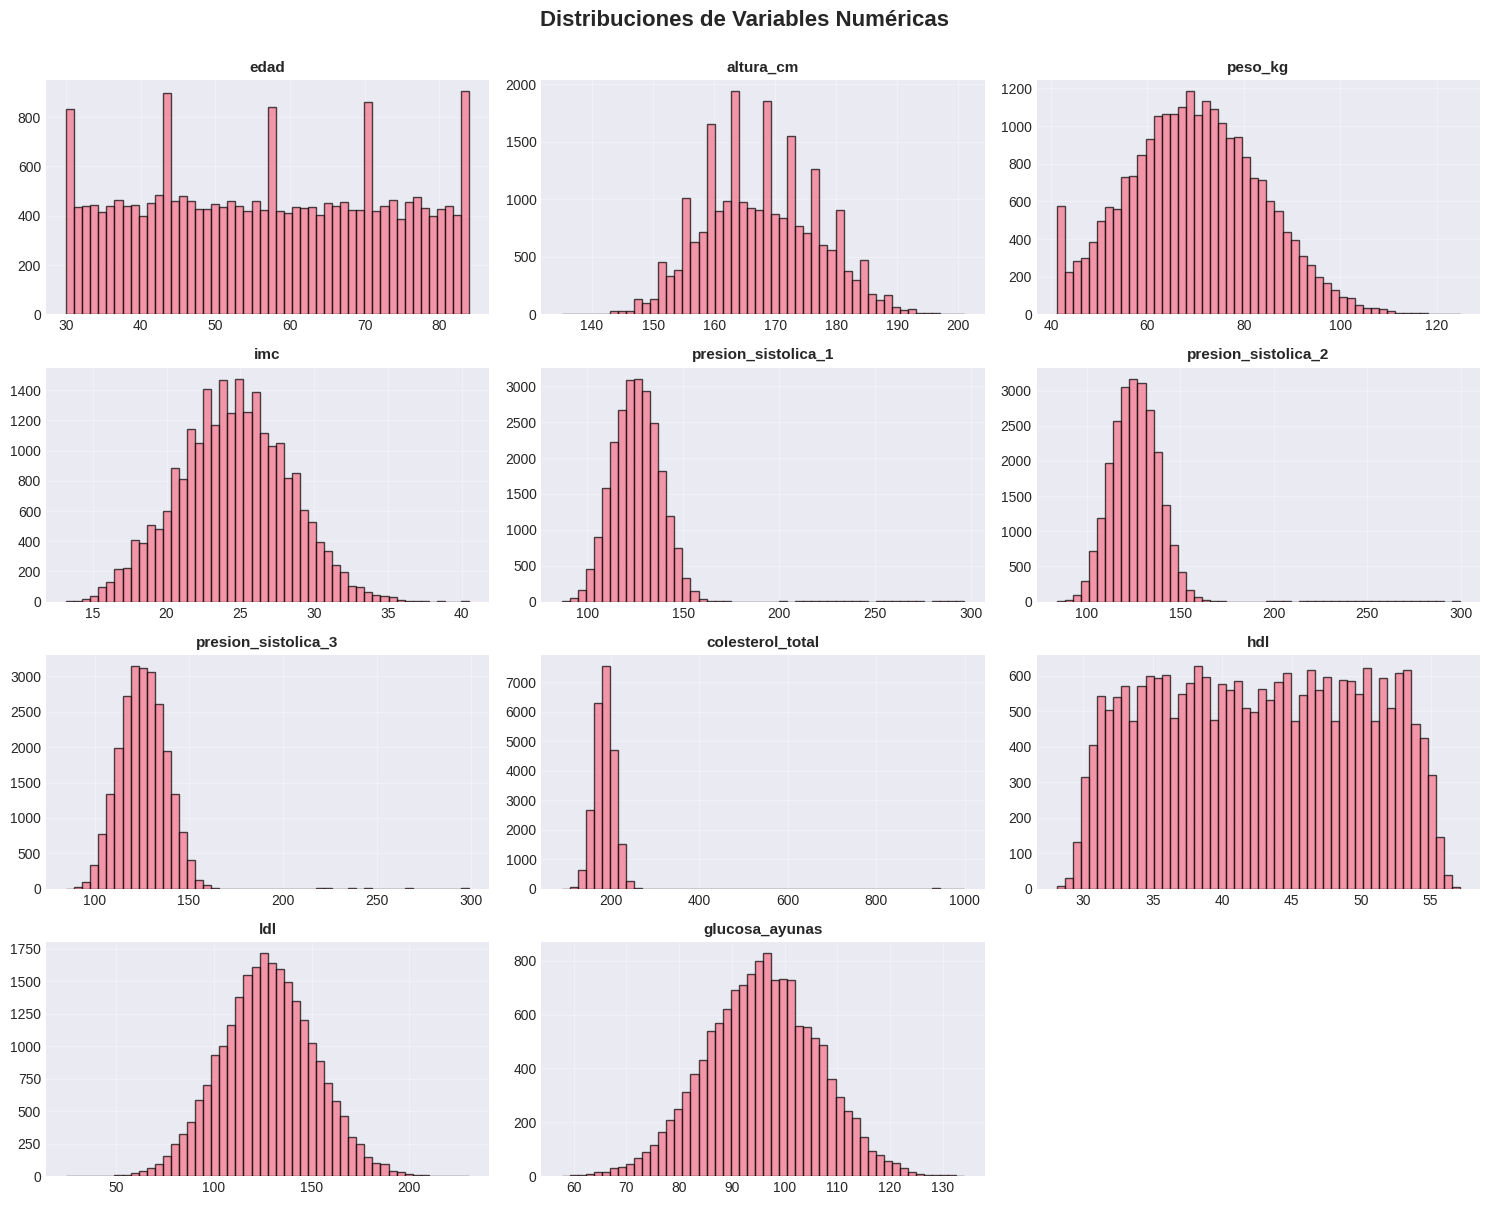

In [30]:
# Visualización de distribuciones
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(vars_numericas_continuas):
    # Histograma con KDE
    cardis_df_train[col].hist(bins=50, ax=axes[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].grid(alpha=0.3)

# Ocultar el último subplot si sobra
if len(vars_numericas_continuas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Como podemos ver gracias a estas visualizaciones, no parece que existan una gran cantidad de valores anómalos, por lo que podemos inferir que:
- Si que existen en variables como las presiones sistólicas, el colesterol o el IMC, pero muy probablemente correspondan a casos extremos pero reales, que es importante mantener pues son de vital importancia para nuestro sistema.
- Otras variables no parecen presentar valores anómalos, como la edad (que va de 30 a 84 años y solo tiene valores enteros), el peso (de 40 a 125 kilos, aproximadamente), o la glucosa (entre 60 y 130).

En resumen, estos datos parecen clínicamente posibles, incluso con la presencia de casos extremos, y coinciden con los de pacientes que tendría sentido que acudiesen a atención primaria.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 2. Distribución del target y desbalanceo

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 3. Valores ausentes: análisis y estrategia

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 4. Valores atípicos e inconsistencias

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 5. Correlaciones y relaciones

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 6. Variables de texto libre y categóricas de alta cardinalidad

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 7. Análisis de sesgos poblaciones y equidad